<a href="https://colab.research.google.com/github/mashac136/RealTimeMachineLearning/blob/main/hw2_RNN_LSTM_GRU_MarlyAshac.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# reproducibility
torch.manual_seed(42)
np.random.seed(42)

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# text sequence from the homework
text = """Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."""

# build vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)

# character to index and index to character
char_to_idx = {ch: idx for idx, ch in enumerate(chars)}
idx_to_char = {idx: ch for idx, ch in enumerate(chars)}

print(f"Text length: {len(text)} characters")
print(f"Vocabulary size: {vocab_size} unique characters")
print(f"First 10 chars in vocab: {chars[:10]}")

Text length: 2391 characters
Vocabulary size: 45 unique characters
First 10 chars in vocab: ['\n', ' ', "'", '(', ')', ',', '-', '.', 'A', 'D']


In [ ]:
class CharDataset(Dataset):
    def __init__(self, text, char_to_idx, seq_length):
        self.text = text
        self.char_to_idx = char_to_idx
        self.seq_length = seq_length
        self.data = [char_to_idx[ch] for ch in text]

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx : idx + self.seq_length], dtype=torch.long)
        y = torch.tensor(self.data[idx + self.seq_length], dtype=torch.long)
        return x, y

# test
test_dataset = CharDataset(text, char_to_idx, seq_length=10)
x_sample, y_sample = test_dataset[0]
print(f"Input sequence: {''.join([idx_to_char[i.item()] for i in x_sample])}")
print(f"Target character: {idx_to_char[y_sample.item()]}")
print(f"Dataset size: {len(test_dataset)} samples")

Input sequence: Next chara
Target character: c
Dataset size: 2381 samples


In [ ]:
class CharModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, model_type):
        super(CharModel, self).__init__()
        self.model_type = model_type
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        #  converts character indices to vectors
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # RNN LSTM or GRU layer
        if model_type == 'RNN':
            self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True)
        elif model_type == 'LSTM':
            self.rnn = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True)

        # fully connected output layer
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # embed input characters
        x = self.embedding(x)

        # pass through recurrent layer
        out, _ = self.rnn(x)

        # only the last time steps output
        out = self.fc(out[:, -1, :])
        return out

# test
test_model = CharModel(vocab_size, embed_size=64, hidden_size=128, num_layers=2, model_type='LSTM').to(device)
print(f"Model created successfully!")
print(f"Total parameters: {sum(p.numel() for p in test_model.parameters()):,}")

Model created successfully!
Total parameters: 240,109


In [ ]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.003):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # training
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)
                predicted = output.argmax(dim=1)
                correct += (predicted == y).sum().item()
                total += y.size(0)

        val_acc = correct / total * 100
        val_accuracies.append(val_acc)

        # Print every 5 epochs
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return train_losses, val_accuracies

print("Training function ready!")

Training function ready!


In [ ]:
# hyperparameters
embed_size = 64
hidden_size = 128
num_layers = 2
epochs = 20
batch_size = 64
seq_lengths = [10, 20, 30]
model_types = ['RNN', 'LSTM', 'GRU']

# store results
results = {}

for seq_len in seq_lengths:
    # create dataset and split into train/val (80/20)
    dataset = CharDataset(text, char_to_idx, seq_len)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    for model_type in model_types:
        print(f"\nTraining {model_type} | Seq Length: {seq_len}")

        # build model
        model = CharModel(vocab_size, embed_size, hidden_size, num_layers, model_type).to(device)

        # model size
        num_params = sum(p.numel() for p in model.parameters())

        # train and time it
        start_time = time.time()
        train_losses, val_accuracies = train_model(model, train_loader, val_loader, epochs)
        elapsed_time = time.time() - start_time

        # store results
        results[(model_type, seq_len)] = {
            'train_losses': train_losses,
            'val_accuracies': val_accuracies,
            'final_loss': train_losses[-1],
            'final_val_acc': val_accuracies[-1],
            'time': elapsed_time,
            'num_params': num_params
        }

        print(f"Done! Time: {elapsed_time:.2f}s | Final Loss: {train_losses[-1]:.4f} | Final Val Acc: {val_accuracies[-1]:.2f}%")

print("\nAll experiments complete!")


Training RNN | Seq Length: 10
Epoch 5/20 | Loss: 1.5243 | Val Acc: 45.07%
Epoch 10/20 | Loss: 0.7427 | Val Acc: 46.33%
Epoch 15/20 | Loss: 0.3157 | Val Acc: 49.48%
Epoch 20/20 | Loss: 0.1670 | Val Acc: 46.54%
Done! Time: 5.00s | Final Loss: 0.1670 | Final Val Acc: 46.54%

Training LSTM | Seq Length: 10
Epoch 5/20 | Loss: 1.8831 | Val Acc: 43.82%
Epoch 10/20 | Loss: 0.9970 | Val Acc: 46.75%
Epoch 15/20 | Loss: 0.3902 | Val Acc: 48.43%
Epoch 20/20 | Loss: 0.1316 | Val Acc: 49.27%
Done! Time: 2.19s | Final Loss: 0.1316 | Final Val Acc: 49.27%

Training GRU | Seq Length: 10
Epoch 5/20 | Loss: 1.5651 | Val Acc: 44.03%
Epoch 10/20 | Loss: 0.5725 | Val Acc: 49.48%
Epoch 15/20 | Loss: 0.1763 | Val Acc: 47.38%
Epoch 20/20 | Loss: 0.0726 | Val Acc: 48.64%
Done! Time: 2.04s | Final Loss: 0.0726 | Final Val Acc: 48.64%

Training RNN | Seq Length: 20
Epoch 5/20 | Loss: 1.5184 | Val Acc: 42.32%
Epoch 10/20 | Loss: 0.7788 | Val Acc: 45.26%
Epoch 15/20 | Loss: 0.3649 | Val Acc: 43.37%
Epoch 20/20 | L

In [ ]:
# results in a comparison table
print(f"{'Model':<6} {'SeqLen':<8} {'Final Loss':<12} {'Val Acc %':<12} {'Time (s)':<12} {'Params':<10}")
print("-" * 60)

for seq_len in seq_lengths:
    for model_type in model_types:
        r = results[(model_type, seq_len)]
        print(f"{model_type:<6} {seq_len:<8} {r['final_loss']:<12.4f} {r['final_val_acc']:<12.2f} {r['time']:<12.2f} {r['num_params']:<10,}")
    print()

Model  SeqLen   Final Loss   Val Acc %    Time (s)     Params    
------------------------------------------------------------
RNN    10       0.1670       46.54        5.00         66,541    
LSTM   10       0.1316       49.27        2.19         240,109   
GRU    10       0.0726       48.64        2.04         182,253   

RNN    20       0.1992       41.47        1.91         66,541    
LSTM   20       0.1803       46.32        2.19         240,109   
GRU    20       0.0748       43.37        2.01         182,253   

RNN    30       0.1725       42.49        1.97         66,541    
LSTM   30       0.2546       45.67        2.24         240,109   
GRU    30       0.0856       47.57        2.11         182,253   



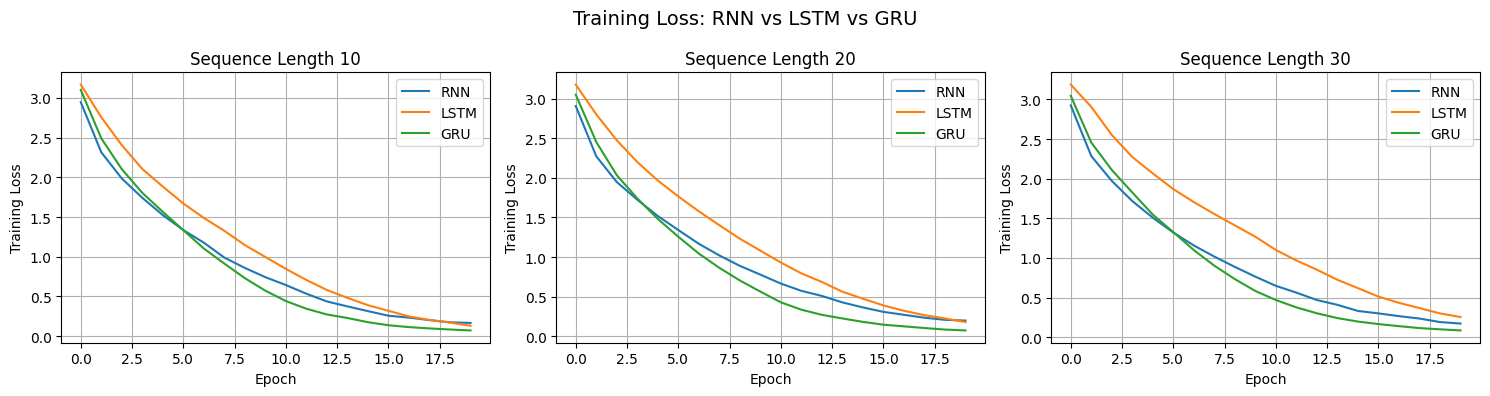

Plot saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, seq_len in enumerate(seq_lengths):
    for model_type in model_types:
        losses = results[(model_type, seq_len)]['train_losses']
        axes[i].plot(losses, label=model_type)

    axes[i].set_title(f'Sequence Length {seq_len}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Training Loss')
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle('Training Loss: RNN vs LSTM vs GRU', fontsize=14)
plt.tight_layout()
plt.savefig('problem1_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

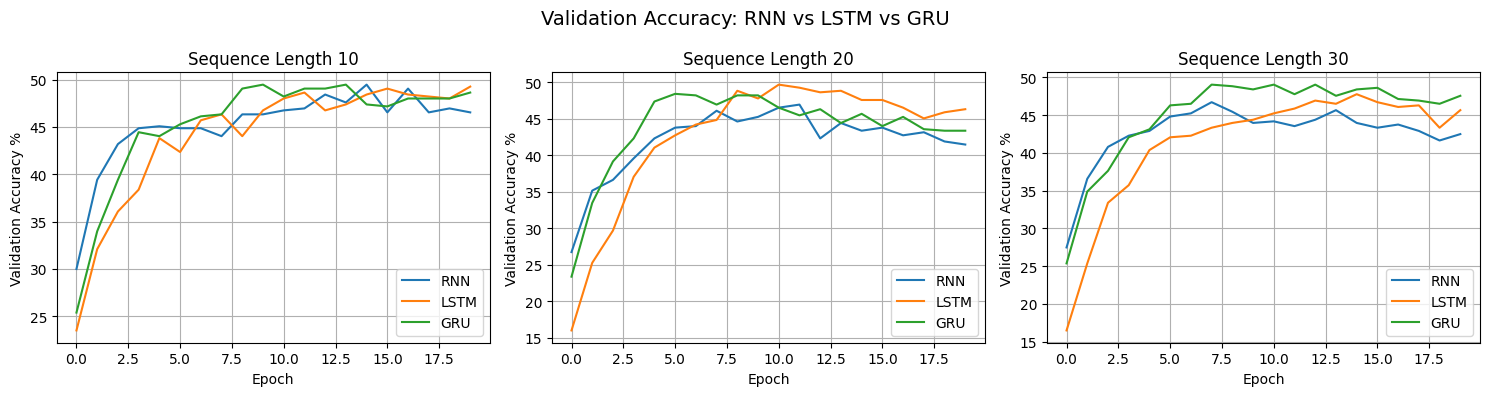

Plot saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, seq_len in enumerate(seq_lengths):
    for model_type in model_types:
        accs = results[(model_type, seq_len)]['val_accuracies']
        axes[i].plot(accs, label=model_type)

    axes[i].set_title(f'Sequence Length {seq_len}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Validation Accuracy %')
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle('Validation Accuracy: RNN vs LSTM vs GRU', fontsize=14)
plt.tight_layout()
plt.savefig('problem1_val_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [ ]:
import urllib.request

# download shakespeare dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(url, "shakespeare.txt")

# load and preview
with open("shakespeare.txt", "r") as f:
    shakespeare_text = f.read()

print(f"Text length: {len(shakespeare_text):,} characters")
print(f"\nFirst 200 characters:\n{shakespeare_text[:200]}")

Text length: 1,115,394 characters

First 200 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [ ]:
# build vocabulary from shakespeare text
chars = sorted(list(set(shakespeare_text)))
vocab_size = len(chars)

char_to_idx = {ch: idx for idx, ch in enumerate(chars)}
idx_to_char = {idx: ch for idx, ch in enumerate(chars)}

print(f"Vocabulary size: {vocab_size} unique characters")

Vocabulary size: 65 unique characters


In [ ]:
def train_model_p2(model, train_loader, val_loader, epochs=20, lr=0.003):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # training phase
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # validation phase
        model.eval()
        correct = 0
        total = 0
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)
                loss = criterion(output, y)
                val_loss += loss.item()
                predicted = output.argmax(dim=1)
                correct += (predicted == y).sum().item()
                total += y.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        # compute validation accuracy
        val_acc = correct / total * 100
        val_accuracies.append(val_acc)

        # print every 5 epochs
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, val_accuracies

print("Problem 2 training function ready!")

Problem 2 training function ready!


In [ ]:
# hyperparameters for base experiments
embed_size = 64
hidden_size = 128
num_layers = 2
epochs = 20
batch_size = 128  # larger batch size for bigger dataset
seq_lengths_p2 = [20, 30]
model_types_p2 = ['LSTM', 'GRU']

# store results
results_prob2 = {}

for seq_len in seq_lengths_p2:
    # create dataset and split 80/20
    dataset = CharDataset(shakespeare_text, char_to_idx, seq_len)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    for model_type in model_types_p2:
        print(f"\nTraining {model_type} | Seq Length: {seq_len}")

        # build model
        model = CharModel(vocab_size, embed_size, hidden_size, num_layers, model_type).to(device)
        number_parameters = sum(p.numel() for p in model.parameters())

        # train and time it
        time_start = time.time()
        train_losses, val_losses, val_accs = train_model_p2(model, train_loader, val_loader, epochs)
        elapsed_time = time.time() - time_start

        # store results
        results_prob2[(model_type, seq_len, 'base')] = {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_accuracies': val_accs,
            'final_train_loss': train_losses[-1],
            'final_val_loss': val_losses[-1],
            'final_val_acc': val_accs[-1],
            'time': elapsed_time,
            'num_params': number_parameters
        }

        print(f"Done! Time: {elapsed_time:.2f}s | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}%")

print("\nBase experiments complete!")


Training LSTM | Seq Length: 20
Epoch 5/20 | Train Loss: 1.4148 | Val Loss: 1.4359 | Val Acc: 55.87%
Epoch 10/20 | Train Loss: 1.3931 | Val Loss: 1.4278 | Val Acc: 56.15%
Epoch 15/20 | Train Loss: 1.3930 | Val Loss: 1.4345 | Val Acc: 56.04%
Epoch 20/20 | Train Loss: 1.3962 | Val Loss: 1.4335 | Val Acc: 56.11%
Done! Time: 715.92s | Train Loss: 1.3962 | Val Loss: 1.4335 | Val Acc: 56.11%

Training GRU | Seq Length: 20
Epoch 5/20 | Train Loss: 1.6504 | Val Loss: 1.6823 | Val Acc: 49.61%
Epoch 10/20 | Train Loss: 1.8519 | Val Loss: 1.8688 | Val Acc: 44.62%
Epoch 15/20 | Train Loss: 1.9026 | Val Loss: 1.9230 | Val Acc: 43.42%
Epoch 20/20 | Train Loss: 2.0053 | Val Loss: 2.0310 | Val Acc: 40.69%
Done! Time: 609.60s | Train Loss: 2.0053 | Val Loss: 2.0310 | Val Acc: 40.69%

Training LSTM | Seq Length: 30
Epoch 5/20 | Train Loss: 1.4078 | Val Loss: 1.4316 | Val Acc: 56.31%
Epoch 10/20 | Train Loss: 1.3766 | Val Loss: 1.4130 | Val Acc: 56.64%
Epoch 15/20 | Train Loss: 1.3708 | Val Loss: 1.4114 

In [ ]:
# retrain GRU with lower learning rate - previous lr=0.003 caused divergence
for seq_len in seq_lengths_p2:
    dataset = CharDataset(shakespeare_text, char_to_idx, seq_len)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    print(f"\nRetraining GRU | Seq Length: {seq_len}")
    model = CharModel(vocab_size, embed_size, hidden_size, num_layers, 'GRU').to(device)
    number_parameters = sum(p.numel() for p in model.parameters())

    time_start = time.time()
    train_losses, val_losses, val_accs = train_model_p2(model, train_loader, val_loader, epochs, lr=0.0005)
    elapsed_time = time.time() - time_start

    # overwrite previous GRU results
    results_prob2[('GRU', seq_len, 'base')] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accs,
        'final_train_loss': train_losses[-1],
        'final_val_loss': val_losses[-1],
        'final_val_acc': val_accs[-1],
        'time': elapsed_time,
        'num_params': number_parameters
    }

    print(f"Done! Time: {elapsed_time:.2f}s | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}%")


Retraining GRU | Seq Length: 20
Epoch 5/20 | Train Loss: 1.3918 | Val Loss: 1.4158 | Val Acc: 56.69%
Epoch 10/20 | Train Loss: 1.3203 | Val Loss: 1.3809 | Val Acc: 57.66%
Epoch 15/20 | Train Loss: 1.2867 | Val Loss: 1.3677 | Val Acc: 58.10%
Epoch 20/20 | Train Loss: 1.2662 | Val Loss: 1.3661 | Val Acc: 58.22%
Done! Time: 646.54s | Train Loss: 1.2662 | Val Loss: 1.3661 | Val Acc: 58.22%

Retraining GRU | Seq Length: 30
Epoch 5/20 | Train Loss: 1.3836 | Val Loss: 1.4021 | Val Acc: 57.40%
Epoch 10/20 | Train Loss: 1.3113 | Val Loss: 1.3691 | Val Acc: 58.13%
Epoch 15/20 | Train Loss: 1.2781 | Val Loss: 1.3563 | Val Acc: 58.44%
Epoch 20/20 | Train Loss: 1.2571 | Val Loss: 1.3547 | Val Acc: 58.65%
Done! Time: 731.15s | Train Loss: 1.2571 | Val Loss: 1.3547 | Val Acc: 58.65%


In [ ]:
# display base results table
print(f"{'Model':<6} {'SeqLen':<8} {'Train Loss':<12} {'Val Loss':<10} {'Val Acc %':<12} {'Time (s)':<12} {'Params':<10}")
print("-" * 70)

for seq_len in seq_lengths_p2:
    for model_type in model_types_p2:
        r = results_prob2[(model_type, seq_len, 'base')]
        print(f"{model_type:<6} {seq_len:<8} {r['final_train_loss']:<12.4f} {r['final_val_loss']:<10.4f} {r['final_val_acc']:<12.2f} {r['time']:<12.2f} {r['num_params']:<10,}")
    print()

Model  SeqLen   Train Loss   Val Loss   Val Acc %    Time (s)     Params    
----------------------------------------------------------------------
LSTM   20       1.3962       1.4335     56.11        715.92       243,969   
GRU    20       1.2662       1.3661     58.22        646.54       186,113   

LSTM   30       1.3737       1.4085     56.73        886.82       243,969   
GRU    30       1.2571       1.3547     58.65        731.15       186,113   



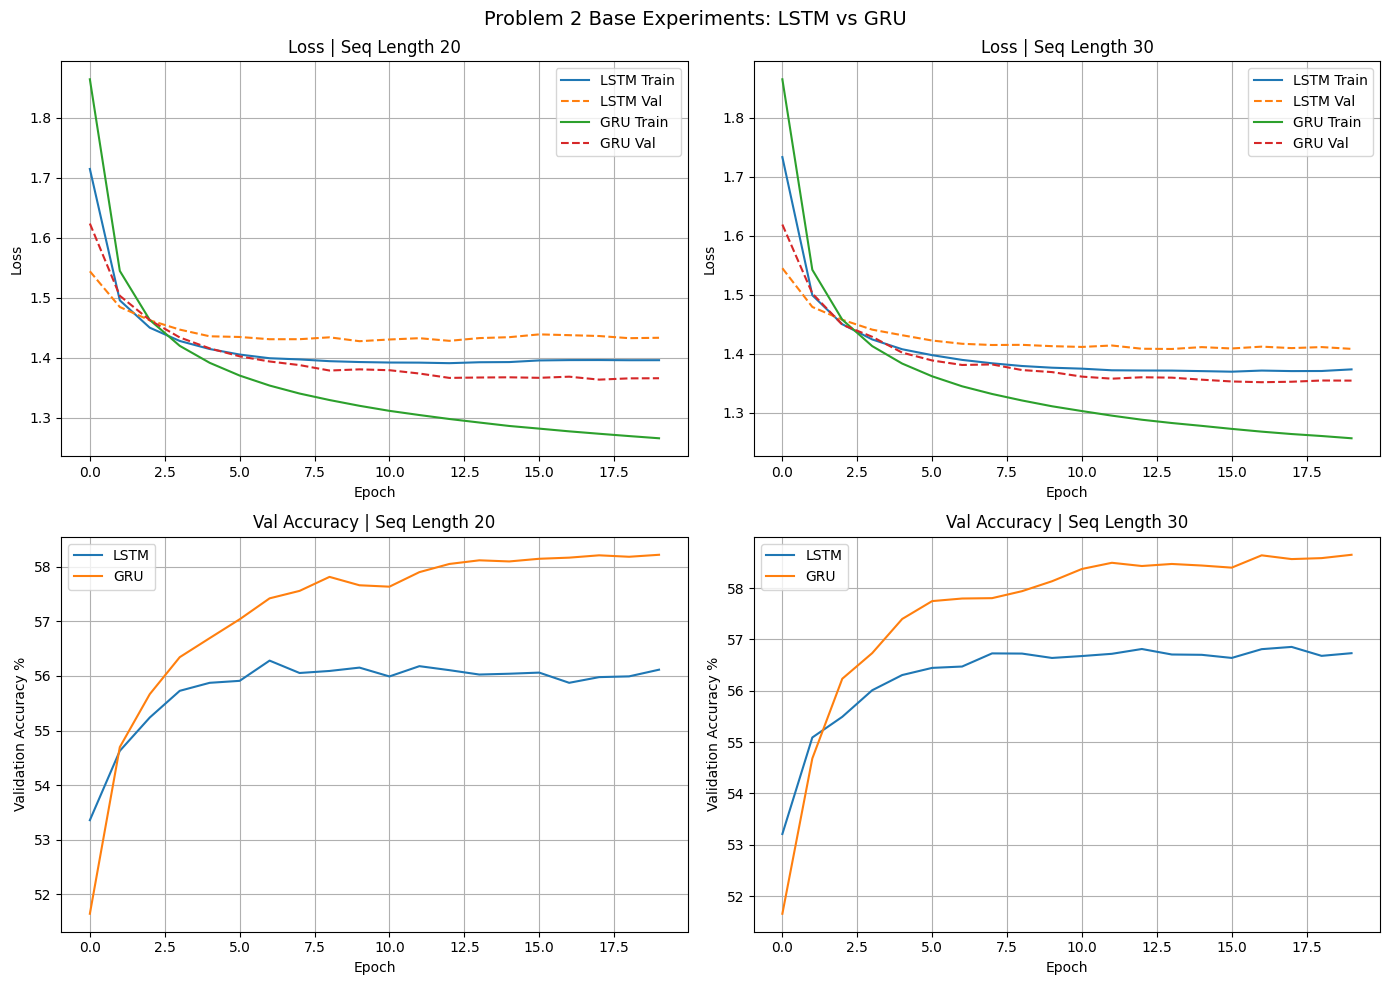

Plot saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, seq_len in enumerate(seq_lengths_p2):
    for model_type in model_types_p2:
        r = results_prob2[(model_type, seq_len, 'base')]
        # Plot training and validation loss
        axes[0, i].plot(r['train_losses'], label=f'{model_type} Train')
        axes[0, i].plot(r['val_losses'], label=f'{model_type} Val', linestyle='--')
        # Plot validation accuracy
        axes[1, i].plot(r['val_accuracies'], label=model_type)

    axes[0, i].set_title(f'Loss | Seq Length {seq_len}')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].legend()
    axes[0, i].grid(True)

    axes[1, i].set_title(f'Val Accuracy | Seq Length {seq_len}')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('Validation Accuracy %')
    axes[1, i].legend()
    axes[1, i].grid(True)

plt.suptitle('Problem 2 Base Experiments: LSTM vs GRU', fontsize=14)
plt.tight_layout()
plt.savefig('problem2_base.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [ ]:
# hyperparameter using GRU seq_len=20 as base
# base config: hidden_size=128, num_layers=2, embed_size=64

hyperparameter_configs = [
    # (config_name, hidden_size, num_layers, embed_size)
    ('base',         128, 2, 64),   # baseline
    ('large_hidden', 256, 2, 64),   # larger hidden size
    ('deep',         128, 3, 64),   # more layers
    ('large_fc',     128, 2, 128),  # larger embedding/FC
]

results_hyperparam = {}

dataset = CharDataset(shakespeare_text, char_to_idx, 20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

for config_name, hidden_size, num_layers, embed_size in hyperparameter_configs:
    print(f"\nTraining GRU | Config: {config_name} | hidden={hidden_size} layers={num_layers} embed={embed_size}")

    model = CharModel(vocab_size, embed_size, hidden_size, num_layers, 'GRU').to(device)
    number_parameters = sum(p.numel() for p in model.parameters())

    time_start = time.time()
    train_losses, val_losses, val_accs = train_model_p2(model, train_loader, val_loader, epochs=20, lr=0.0005)
    elapsed_time = time.time() - time_start

    results_hyperparam[config_name] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accs,
        'final_train_loss': train_losses[-1],
        'final_val_loss': val_losses[-1],
        'final_val_acc': val_accs[-1],
        'time': elapsed_time,
        'num_params': number_parameters,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'embed_size': embed_size
    }

    print(f"Done! Time: {elapsed_time:.2f}s | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}% | Params: {number_parameters:,}")

print("\nHyperparameter experiments complete!")


Training GRU | Config: base | hidden=128 layers=2 embed=64
Epoch 5/20 | Train Loss: 1.3907 | Val Loss: 1.4201 | Val Acc: 56.65%
Epoch 10/20 | Train Loss: 1.3204 | Val Loss: 1.3821 | Val Acc: 57.63%
Epoch 15/20 | Train Loss: 1.2865 | Val Loss: 1.3726 | Val Acc: 57.83%
Epoch 20/20 | Train Loss: 1.2659 | Val Loss: 1.3695 | Val Acc: 58.02%
Done! Time: 677.67s | Train Loss: 1.2659 | Val Loss: 1.3695 | Val Acc: 58.02% | Params: 186,113

Training GRU | Config: large_hidden | hidden=256 layers=2 embed=64
Epoch 5/20 | Train Loss: 1.2902 | Val Loss: 1.3518 | Val Acc: 58.23%
Epoch 10/20 | Train Loss: 1.2062 | Val Loss: 1.3472 | Val Acc: 58.51%
Epoch 15/20 | Train Loss: 1.1624 | Val Loss: 1.3639 | Val Acc: 58.60%
Epoch 20/20 | Train Loss: 1.1405 | Val Loss: 1.3817 | Val Acc: 58.13%
Done! Time: 1025.41s | Train Loss: 1.1405 | Val Loss: 1.3817 | Val Acc: 58.13% | Params: 662,913

Training GRU | Config: deep | hidden=128 layers=3 embed=64
Epoch 5/20 | Train Loss: 1.3658 | Val Loss: 1.3982 | Val Acc:

In [ ]:
# hyperparameter comparison table
print(f"{'Config':<14} {'Hidden':<8} {'Layers':<8} {'Embed':<7} {'Train Loss':<12} {'Val Loss':<10} {'Val Acc %':<12} {'Time (s)':<12} {'Params':<10}")
print("-" * 90)

for config_name, hidden_size, num_layers, embed_size in hyperparameter_configs:
    r = results_hyperparam[config_name]
    print(f"{config_name:<14} {hidden_size:<8} {num_layers:<8} {embed_size:<7} {r['final_train_loss']:<12.4f} {r['final_val_loss']:<10.4f} {r['final_val_acc']:<12.2f} {r['time']:<12.2f} {r['num_params']:<10,}")

Config         Hidden   Layers   Embed   Train Loss   Val Loss   Val Acc %    Time (s)     Params    
------------------------------------------------------------------------------------------
base           128      2        64      1.2659       1.3695     58.02        677.67       186,113   
large_hidden   256      2        64      1.1405       1.3817     58.13        1025.41      662,913   
deep           128      3        64      1.2244       1.3620     58.36        767.26       285,185   
large_fc       128      2        128     1.2719       1.3714     57.96        672.82       214,849   


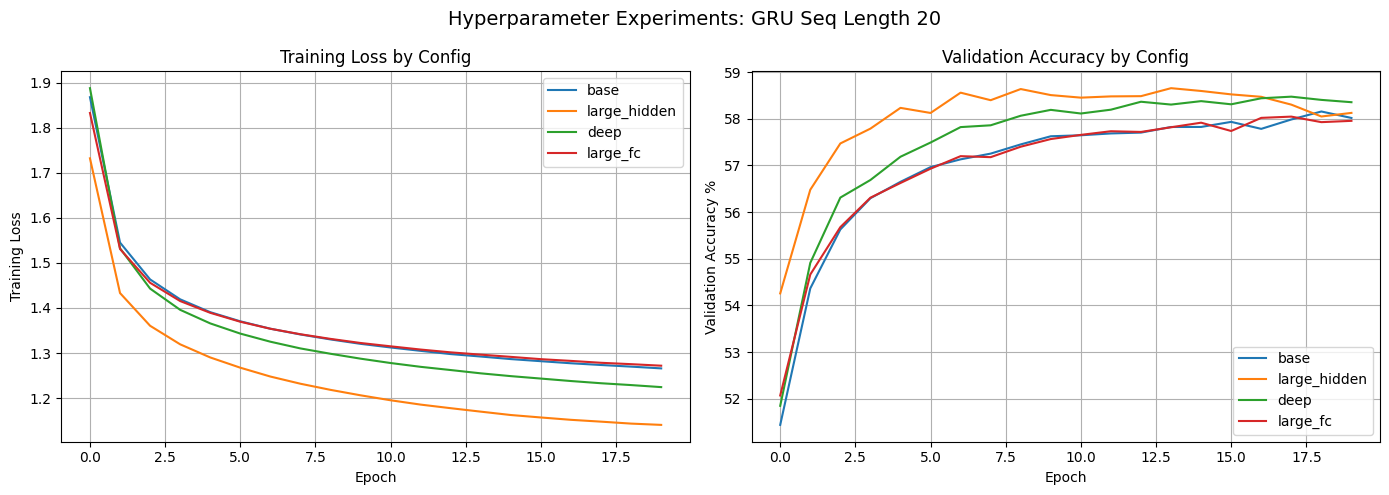

Plot saved!


In [ ]:
#hyperparameter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for config_name, _, _, _ in hyperparameter_configs:
    r = results_hyperparam[config_name]
    # Plot training loss
    axes[0].plot(r['train_losses'], label=config_name)
    # Plot validation accuracy
    axes[1].plot(r['val_accuracies'], label=config_name)

axes[0].set_title('Training Loss by Config')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Validation Accuracy by Config')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy %')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Hyperparameter Experiments: GRU Seq Length 20', fontsize=14)
plt.tight_layout()
plt.savefig('problem2_hyperparam.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [ ]:
def generate_text(model, start_text, char_to_idx, idx_to_char, length=200):
    model.eval()
    # convert start text to indices
    input_seq = torch.tensor([char_to_idx[ch] for ch in start_text], dtype=torch.long).unsqueeze(0).to(device)

    generated = start_text
    with torch.no_grad():
        for _ in range(length):
            output = model(input_seq)
            # sample from top predictions for more natural text
            probs = torch.softmax(output[0] / 0.8, dim=0)
            next_idx = torch.multinomial(probs, 1).item()
            next_char = idx_to_char[next_idx]
            generated += next_char
            # slide the window forward
            next_tensor = torch.tensor([[next_idx]], dtype=torch.long).to(device)
            input_seq = torch.cat([input_seq[:, 1:], next_tensor], dim=1)

    return generated

# retrain base GRU and save model object for text generation
print("Retraining base GRU for text generation...")
base_model = CharModel(vocab_size, 64, 128, 2, 'GRU').to(device)
dataset = CharDataset(shakespeare_text, char_to_idx, 20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
train_model_p2(base_model, train_loader, val_loader, epochs=20, lr=0.0005)

# generate text
print("\n--- Generated Text (Base GRU) ---")
print(generate_text(base_model, "To be or not to be", char_to_idx, idx_to_char))

Retraining base GRU for text generation...
Epoch 5/20 | Train Loss: 1.3915 | Val Loss: 1.4128 | Val Acc: 56.93%
Epoch 10/20 | Train Loss: 1.3214 | Val Loss: 1.3746 | Val Acc: 57.83%
Epoch 15/20 | Train Loss: 1.2888 | Val Loss: 1.3650 | Val Acc: 58.10%
Epoch 20/20 | Train Loss: 1.2684 | Val Loss: 1.3620 | Val Acc: 58.07%

--- Generated Text (Base GRU) ---
To be or not to bed,
His affied is now made, my brother, and young
The clouds away.

ROMEO:
But I say that Petruchio I will,
The villain of the mornings
behind me with us, hath promised him flowed.

MENENIUS:
You shoul


In [ ]:
# train LSTM and GRU on sequence length 50
seq_len_50_results = {}

dataset = CharDataset(shakespeare_text, char_to_idx, 50)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

for model_type in model_types_p2:
    print(f"\nTraining {model_type} | Seq Length: 50")

    model = CharModel(vocab_size, 64, 128, 2, model_type).to(device)
    number_parameters = sum(p.numel() for p in model.parameters())
    lr = 0.0005 if model_type == 'GRU' else 0.003

    time_start = time.time()
    train_losses, val_losses, val_accs = train_model_p2(model, train_loader, val_loader, epochs=20, lr=lr)
    elapsed_time = time.time() - time_start

    seq_len_50_results[model_type] = {
        'final_train_loss': train_losses[-1],
        'final_val_loss': val_losses[-1],
        'final_val_acc': val_accs[-1],
        'time': elapsed_time,
        'num_params': number_parameters,
        'perplexity': np.exp(val_losses[-1]),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accs
    }

    print(f"Done! Time: {elapsed_time:.2f}s | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}% | Perplexity: {np.exp(val_losses[-1]):.2f}")

print("\nSeq length 50 complete!")


Training LSTM | Seq Length: 50
Epoch 5/20 | Train Loss: 1.3957 | Val Loss: 1.4206 | Val Acc: 56.47%
Epoch 10/20 | Train Loss: 1.3665 | Val Loss: 1.4063 | Val Acc: 56.91%
Epoch 15/20 | Train Loss: 1.3617 | Val Loss: 1.4016 | Val Acc: 56.74%
Epoch 20/20 | Train Loss: 1.3661 | Val Loss: 1.4063 | Val Acc: 56.94%
Done! Time: 1233.80s | Train Loss: 1.3661 | Val Loss: 1.4063 | Val Acc: 56.94% | Perplexity: 4.08

Training GRU | Seq Length: 50
Epoch 5/20 | Train Loss: 1.3723 | Val Loss: 1.3968 | Val Acc: 57.47%
Epoch 10/20 | Train Loss: 1.2994 | Val Loss: 1.3598 | Val Acc: 58.46%
Epoch 15/20 | Train Loss: 1.2651 | Val Loss: 1.3473 | Val Acc: 58.80%
Epoch 20/20 | Train Loss: 1.2433 | Val Loss: 1.3429 | Val Acc: 59.01%
Done! Time: 929.53s | Train Loss: 1.2433 | Val Loss: 1.3429 | Val Acc: 59.01% | Perplexity: 3.83

Seq length 50 complete!


In [ ]:
# calculate perplexity and measure inference time using base_model
import math

print(f"{'Config':<14} {'Train Loss':<12} {'Val Loss':<10} {'Val Acc %':<12} {'Perplexity':<12} {'Inference (ms)':<16} {'Params':<10}")
print("-" * 85)

# measure inference time using base_model for all configs (same architecture reference)
model.eval()
input_seq = torch.tensor([[char_to_idx[ch] for ch in "To be or not to be  "]], dtype=torch.long).to(device)

for config_name, hidden_size, num_layers, embed_size in hyperparameter_configs:
    r = results_hyperparam[config_name]
    perplexity = math.exp(r['final_val_loss'])

    # measure inference time over 100 runs
    time_start = time.time()
    with torch.no_grad():
        for _ in range(100):
            _ = base_model(input_seq)
    inference_time = (time.time() - time_start) / 100 * 1000  # ms per run

    print(f"{config_name:<14} {r['final_train_loss']:<12.4f} {r['final_val_loss']:<10.4f} {r['final_val_acc']:<12.2f} {perplexity:<12.2f} {inference_time:<16.2f} {r['num_params']:<10,}")

Config         Train Loss   Val Loss   Val Acc %    Perplexity   Inference (ms)   Params    
-------------------------------------------------------------------------------------
base           1.2659       1.3695     58.02        3.93         0.40             186,113   
large_hidden   1.1405       1.3817     58.13        3.98         0.33             662,913   
deep           1.2244       1.3620     58.36        3.90         0.33             285,185   
large_fc       1.2719       1.3714     57.96        3.94         0.33             214,849   


In [ ]:
# generate sample output sequences using base_model
start_text = "To be or not to be"

for config_name, hidden_size, num_layers, embed_size in hyperparameter_configs:
    print(f"\n--- Config: {config_name} (hidden={hidden_size}, layers={num_layers}, embed={embed_size}) ---")
    print(generate_text(base_model, start_text, char_to_idx, idx_to_char))


--- Config: base (hidden=128, layers=2, embed=64) ---
To be or not to be king,
To be a dear dispite and stranger drinking.

COMINIUS:
Now, she stand had advance:
And look it, the joys,
Or when some of strength
To hear Kate herself
But most many hands, you must be so,
Had 

--- Config: large_hidden (hidden=256, layers=2, embed=64) ---
To be or not to be from that we did be my cried
Best be fortune in them.

LEONTES:
Look, no, noble Tower?

JULIET:
What name is I am convey, to have done a poor sound in the death before me to what here she shall make 

--- Config: deep (hidden=128, layers=3, embed=64) ---
To be or not to be seven from the common within my father come resolved
That is low he is like blood that make a pimitious wall,
And these thanks with my in such alto
To them to my death?
Or what is now counsel you but

--- Config: large_fc (hidden=128, layers=2, embed=128) ---
To be or not to be construpted
Enving and Stranger.

PETRUCHIO:
Them home to be;
And I will so will fawns to t

In [ ]:
# seq length 50 results table
print(f"{'Model':<6} {'SeqLen':<8} {'Train Loss':<12} {'Val Loss':<10} {'Val Acc %':<12} {'Perplexity':<12} {'Time (s)':<12} {'Params':<10}")
print("-" * 80)

for model_type in model_types_p2:
    r = seq_len_50_results[model_type]
    print(f"{model_type:<6} {50:<8} {r['final_train_loss']:<12.4f} {r['final_val_loss']:<10.4f} {r['final_val_acc']:<12.2f} {r['perplexity']:<12.2f} {r['time']:<12.2f} {r['num_params']:<10,}")

Model  SeqLen   Train Loss   Val Loss   Val Acc %    Perplexity   Time (s)     Params    
--------------------------------------------------------------------------------
LSTM   50       1.3661       1.4063     56.94        4.08         1233.80      243,969   
GRU    50       1.2433       1.3429     59.01        3.83         929.53       186,113   


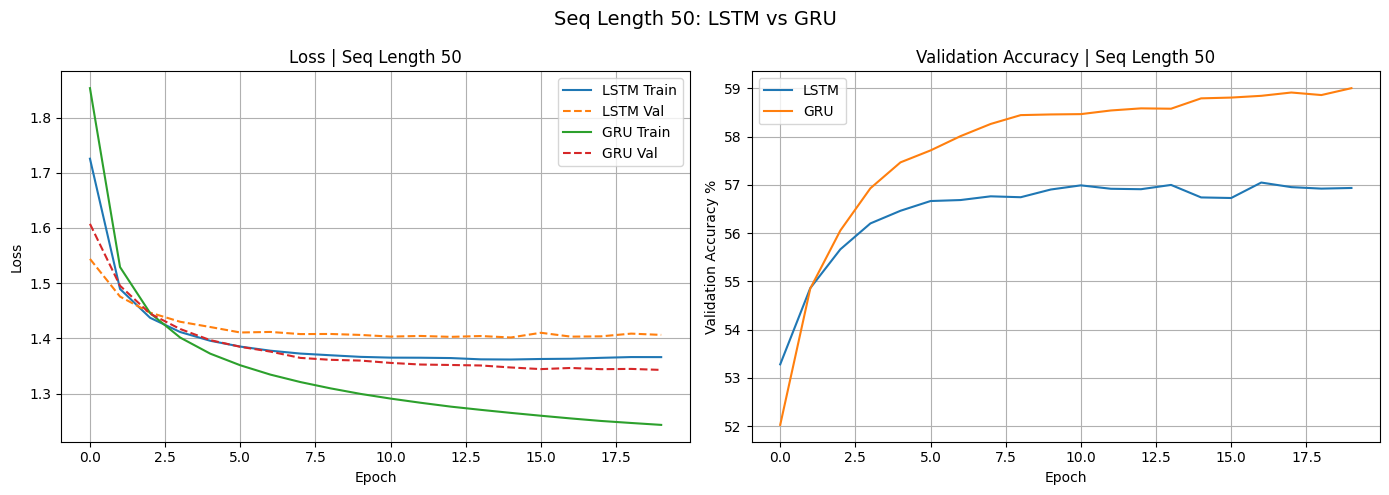

Plot saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_type in model_types_p2:
    r = seq_len_50_results[model_type]
    axes[0].plot(r['train_losses'], label=f'{model_type} Train')
    axes[0].plot(r['val_losses'], label=f'{model_type} Val', linestyle='--')
    axes[1].plot(r['val_accuracies'], label=model_type)

axes[0].set_title('Loss | Seq Length 50')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Validation Accuracy | Seq Length 50')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy %')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Seq Length 50: LSTM vs GRU', fontsize=14)
plt.tight_layout()
plt.savefig('problem2_seq50.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")